# Problem
- predict whether a movie is Flop, Average, or Hit based on its features.

In [40]:
## Imports
import pandas as pd
import numpy as np

import sys
from pathlib import Path
PROJECT_ROOT= Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
from src.preprocessing import load_data, build_preprocessor, split_data,extract_cat_col_num_cols

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report





In [41]:
## Load data
df=load_data()
df.head()

,color,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,genres,num_voted_users,cast_total_facebook_likes,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,723.0,178.0,0.0,855.0,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,886204,4834,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,302.0,169.0,563.0,1000.0,40000.0,309404152.0,Action|Adventure|Fantasy,471220,48350,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,602.0,148.0,0.0,161.0,11000.0,200074175.0,Action|Adventure|Thriller,275868,11700,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,813.0,164.0,22000.0,23000.0,27000.0,448130642.0,Action|Thriller,1144337,106759,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,NaN,NaN,131.0,NaN,131.0,NaN,Documentary,8,143,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [42]:
df=df.copy()

In [43]:
## Meta data
print("No.of rows:",df.shape[0])
print("\n No.of columns:",df.shape[1])
print("\n All columns:",df.columns.to_list())
print ("\n Data-types:",df.dtypes)
print("\n Info:")
df.info()
print ("\n no.of Duplicates:",df.duplicated().sum())

No.of rows: 5043

 No.of columns: 21

 All columns: ['color', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'genres', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

 Data-types: color                         object
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_1_facebook_likes       float64
gross                        float64
genres                        object
num_voted_users                int64
cast_total_facebook_likes      int64
facenumber_in_poster         float64
num_user_for_reviews         float64
language                      object
country                       object
content_rating               

In [44]:
## remove duplicates
df.drop_duplicates(inplace = True)
print("Count of Duplicates:",df.duplicated().sum())

Count of Duplicates: 0


In [45]:
## Null values
df.isnull().sum()

color                         19
num_critic_for_reviews        49
duration                      15
director_facebook_likes      103
actor_3_facebook_likes        23
actor_1_facebook_likes         7
gross                        874
genres                         0
num_voted_users                0
cast_total_facebook_likes      0
facenumber_in_poster          13
num_user_for_reviews          21
language                      14
country                        5
content_rating               301
budget                       487
title_year                   107
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 327
movie_facebook_likes           0
dtype: int64

In [46]:
def classify_movie(score):
    if score <= 3:
        return "Flop"
    elif score <= 6:
        return "Average"
    else:
        return "Hit"

df["Classify"] = df["imdb_score"].apply(classify_movie)

In [47]:
df['Classify'].isnull().sum()

np.int64(0)

In [48]:
# Seperate feature and target
X =df.drop(["Classify","imdb_score"],axis=1)     # features
y =df["Classify"]                     # target

In [49]:
# split data
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
print(df['Classify'].value_counts())

Classify
Hit        3428
Average    1524
Flop         46
Name: count, dtype: int64


# Logistic regression

In [51]:
preprocessor = build_preprocessor(X_train)

model_lr = LogisticRegression(max_iter=1000,class_weight="balanced")

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_lr)
])

In [52]:
# Training
pipe_lr.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['color', 'genres',
                                                   'language', 'country',
                                                   'content_rating']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   Standa...
                                                   'director_facebook_likes',
                                                   'actor_3_facebook_likes',
                                                   'actor_1_facebook_likes',
                                                   'gross', 'num_voted_users',
                                                   'cast_total_facebook_likes',
                                                   'facenumber_in_poster',
                                                   'num_user_for_reviews',
                                                   'budget', 'title_year',
                                                   'actor_2_facebook_likes',
                                                   'aspect_ratio',
                                                   'movie_facebook_likes'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [53]:
print(y_train.head())
print(y_train.dtype)
print(y_train.unique()[:10])

1750    Average
4017        Hit
2938        Hit
1607        Hit
3238    Average
Name: Classify, dtype: object
object
['Average' 'Hit' 'Flop']


In [54]:
print(y_train.value_counts())

Classify
Hit        2738
Average    1220
Flop         40
Name: count, dtype: int64


In [55]:
# prediction

y_pred_lr = pipe_lr.predict(X_test)
df_pred_lr = pd.DataFrame({"Actual":y_test, "Prediction":y_pred_lr})
df_pred_lr.head(10)

,Actual,Prediction
84,Average,Average
2485,Hit,Hit
2826,Hit,Hit
5031,Average,Flop
4968,Average,Average
4759,Hit,Average
158,Hit,Hit
713,Average,Average
4700,Average,Average
1190,Average,Hit


In [56]:
### model evaluation
accuracy_lr = accuracy_score(y_test,y_pred_lr)
conf_lr = confusion_matrix(y_test,y_pred_lr)
report_lr= classification_report(y_test,y_pred_lr)


print(f"Model Accuracy of Logistic Regression:{accuracy_lr*100:.2f}%")
print ("\n Classification Report for Logistic Regression: \n",report_lr)
print ("\n Confusion matrix:\n for Logistic Regression",conf_lr)

Model Accuracy of Logistic Regression:73.00%

 Classification Report for Logistic Regression: 
               precision    recall  f1-score   support

     Average       0.57      0.73      0.64       304
        Flop       0.06      0.50      0.11         6
         Hit       0.89      0.73      0.80       690

    accuracy                           0.73      1000
   macro avg       0.51      0.65      0.52      1000
weighted avg       0.79      0.73      0.75      1000


 Confusion matrix:
 for Logistic Regression [[223  21  60]
 [  3   3   0]
 [163  23 504]]


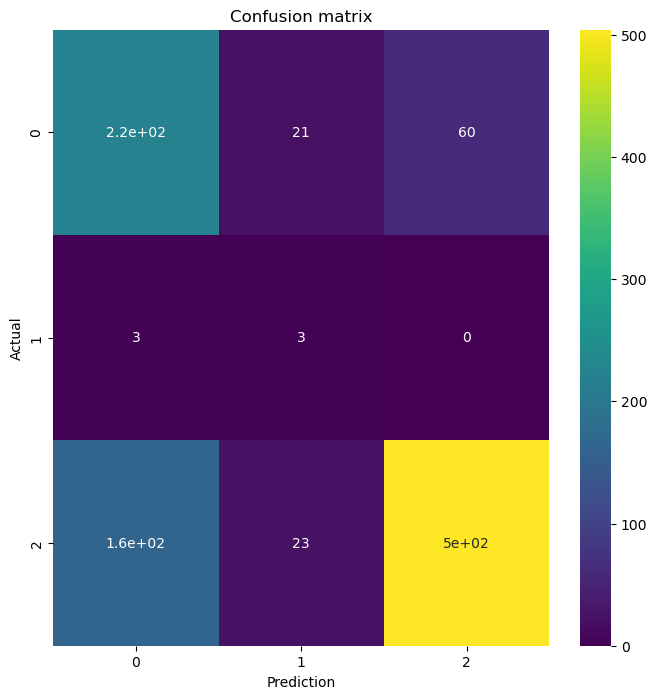

In [57]:
## Visualize a confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(conf_lr,annot = True, cmap ="viridis")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

# Decision Tree

In [58]:
preprocessor = build_preprocessor(X_train)

model_dt = DecisionTreeClassifier()

pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_dt)
])

In [59]:
# Training
pipe_dt.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['color', 'genres',
                                                   'language', 'country',
                                                   'content_rating']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   Standa...
                                                  ['num_critic_for_reviews',
                                                   'duration',
                                                   'director_facebook_likes',
                                                   'actor_3_facebook_likes',
                                                   'actor_1_facebook_likes',
                                                   'gross', 'num_voted_users',
                                                   'cast_total_facebook_likes',
                                                   'facenumber_in_poster',
                                                   'num_user_for_reviews',
                                                   'budget', 'title_year',
                                                   'actor_2_facebook_likes',
                                                   'aspect_ratio',
                                                   'movie_facebook_likes'])],
                                   verbose_feature_names_out=False)),
                ('model', DecisionTreeClassifier())])

In [60]:
# prediction

y_pred_dt = pipe_dt.predict(X_test)
df_pred_dt = pd.DataFrame({"Actual":y_test, "Prediction":y_pred_dt})
df_pred_dt.head(10)

,Actual,Prediction
84,Average,Average
2485,Hit,Hit
2826,Hit,Hit
5031,Average,Average
4968,Average,Hit
4759,Hit,Hit
158,Hit,Hit
713,Average,Hit
4700,Average,Hit
1190,Average,Hit


In [61]:
### model evaluation
accuracy_dt = accuracy_score(y_test,y_pred_dt)
conf_dt = confusion_matrix(y_test,y_pred_dt)
report_dt= classification_report(y_test,y_pred_dt)


print(f"Model Accuracy for Decision Tree:{accuracy_dt*100:.2f}%")
print ("\n Classification Report for Decision Tree: \n",report_dt)
print ("\n Confusion matrix for Decision Tree:\n",conf_dt)

Model Accuracy for Decision Tree:74.20%

 Classification Report for Decision Tree: 
               precision    recall  f1-score   support

     Average       0.58      0.57      0.57       304
        Flop       0.00      0.00      0.00         6
         Hit       0.82      0.82      0.82       690

    accuracy                           0.74      1000
   macro avg       0.47      0.46      0.47      1000
weighted avg       0.74      0.74      0.74      1000


 Confusion matrix for Decision Tree:
 [[173   6 125]
 [  5   0   1]
 [120   1 569]]


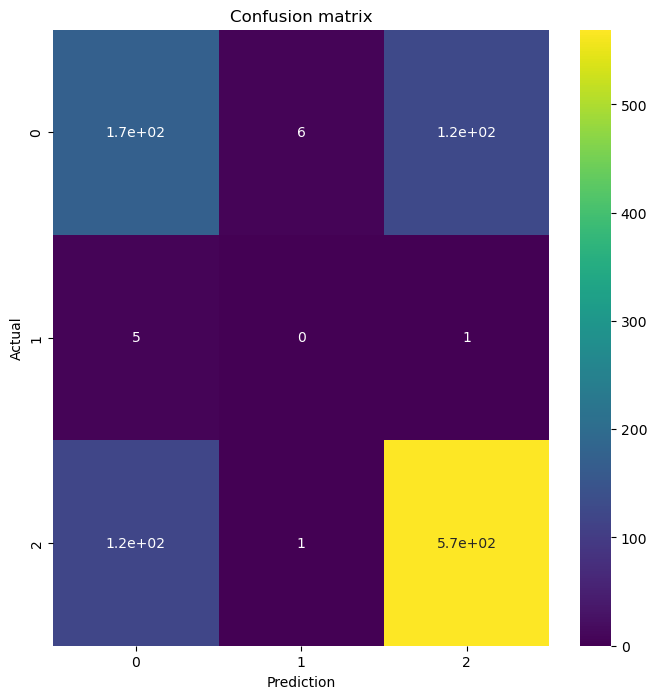

In [62]:
## Visualize a confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(conf_dt,annot = True, cmap ="viridis")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

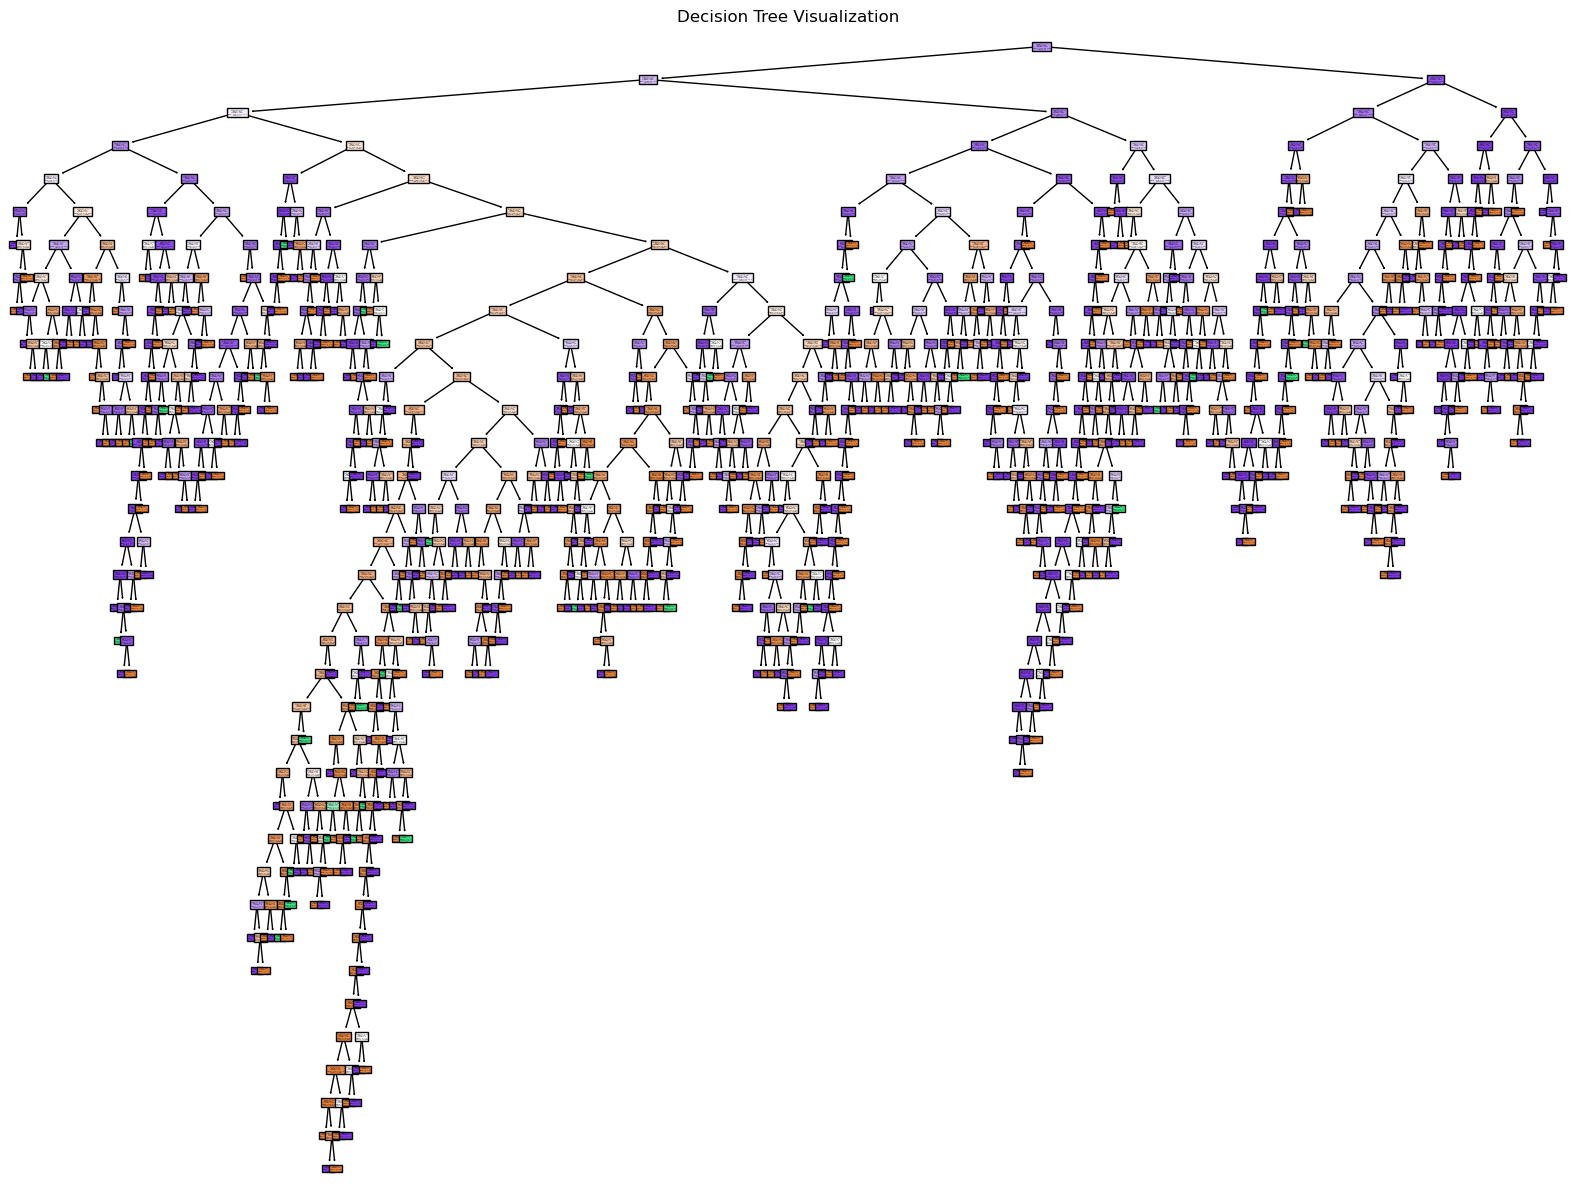

In [63]:
# extract decision tree model from pipeline
clf_dt = pipe_dt.named_steps['model']

plt.figure(figsize=(20,15))

plot_tree(
    clf_dt,
    filled=True,
    class_names=['Average','Flop','Hit']
)

plt.title("Decision Tree Visualization")

plt.show()

# Random Forest

In [64]:
preprocessor = build_preprocessor(X_train)

model_rf = RandomForestClassifier()

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_rf)
])

In [65]:
# Training
pipe_rf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['color', 'genres',
                                                   'language', 'country',
                                                   'content_rating']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   Standa...
                                                  ['num_critic_for_reviews',
                                                   'duration',
                                                   'director_facebook_likes',
                                                   'actor_3_facebook_likes',
                                                   'actor_1_facebook_likes',
                                                   'gross', 'num_voted_users',
                                                   'cast_total_facebook_likes',
                                                   'facenumber_in_poster',
                                                   'num_user_for_reviews',
                                                   'budget', 'title_year',
                                                   'actor_2_facebook_likes',
                                                   'aspect_ratio',
                                                   'movie_facebook_likes'])],
                                   verbose_feature_names_out=False)),
                ('model', RandomForestClassifier())])

In [66]:
# prediction

y_pred_rf = pipe_rf.predict(X_test)
df_pred_rf = pd.DataFrame({"Actual":y_test, "Prediction":y_pred_rf})
df_pred_rf.head(10)

,Actual,Prediction
84,Average,Average
2485,Hit,Hit
2826,Hit,Hit
5031,Average,Hit
4968,Average,Hit
4759,Hit,Hit
158,Hit,Hit
713,Average,Hit
4700,Average,Hit
1190,Average,Hit


In [67]:
### model evaluation
accuracy_rf = accuracy_score(y_test,y_pred_rf)
conf_rf = confusion_matrix(y_test,y_pred_rf)
report_rf= classification_report(y_test,y_pred_rf)


print(f"Model Accuracy for Random Forest :{accuracy_rf*100:.2f}%")
print ("\n Classification Report for Random Forest: \n",report_rf)
print ("\n Confusion matrix for Random Forest:\n",conf_rf)

Model Accuracy for Random Forest :78.70%

 Classification Report for Random Forest: 
               precision    recall  f1-score   support

     Average       0.74      0.46      0.57       304
        Flop       0.00      0.00      0.00         6
         Hit       0.80      0.94      0.86       690

    accuracy                           0.79      1000
   macro avg       0.51      0.47      0.48      1000
weighted avg       0.78      0.79      0.77      1000


 Confusion matrix for Random Forest:
 [[140   0 164]
 [  5   0   1]
 [ 43   0 647]]


C:\Users\SRISHTI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SRISHTI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SRISHTI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


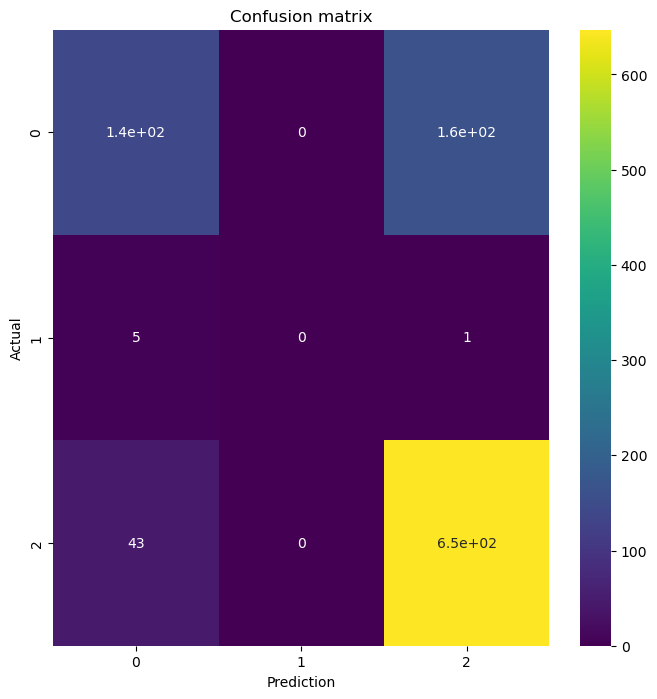

In [68]:
## Visualize a confusion matrix of random Forest
plt.figure(figsize=(8,8))
sns.heatmap(conf_rf,annot = True, cmap ="viridis")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

# Comparison

In [69]:
# putting models in dictionary
models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf
}


In [70]:
## Creating model Comparison Table
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

comparison_df = pd.DataFrame(results)

comparison_df

C:\Users\SRISHTI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.730,0.791251,0.730,0.750968
1,Decision Tree,0.742,0.741390,0.742,0.741670
2,Random Forest,0.787,0.776174,0.787,0.767456


In [71]:
## Finding best model
comparison_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.787,0.776174,0.787,0.767456
1,Decision Tree,0.742,0.741390,0.742,0.741670
0,Logistic Regression,0.730,0.791251,0.730,0.750968


<Axes: xlabel='Model'>

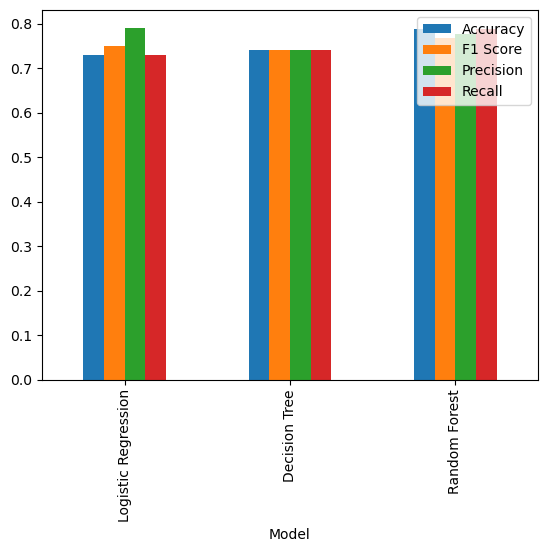

In [72]:
# Visualizing the comparison
comparison_df.set_index("Model")[["Accuracy","F1 Score","Precision","Recall"]].plot(kind="bar")

In [73]:
best_model = pipe_rf
import joblib

joblib.dump(pipe_rf, "best_movie_model.pkl")

['best_movie_model.pkl']